##  คำถามหลัก

1. **Classification Problem คืออะไร?** — การจัดหมวดหมู่ข้อมูลใหม่เข้าไปในคลาสที่กำหนด
2. **ทำไม Machine Learning ถึงแก้ปัญหา Classification ได้?** — เพราะสามารถเรียนรู้ความสัมพันธ์ระหว่าง Features และ Labels
3. **ใช้เทคนิคและเครื่องมืออะไร?** — Decision Trees, KNN, Logistic Regression, Random Forest, SVM
4. **สร้าง Classification Model ได้อย่างไร?** — ใช้ Scikit-learn
5. **Model ดีพอหรือไม่?** — วัดด้วย Accuracy, Precision, Recall

---

##  Dataset: Wisconsin Diagnostic Breast Cancer (WDBC)

- **เป้าหมาย:** พยากรณ์ว่าเนื้องอกเป็น **Malignant** (มะเร็ง) หรือ **Benign** (ไม่ใช่มะเร็ง)
- **จำนวนข้อมูล:** 569 ตัวอย่าง
- **Features:** 30 ค่าที่คำนวณจาก Digital Image ของ Fine-Needle Aspirate (FNA)
- **Labels:** M = Malignant, B = Benign

In [37]:
# Section 1: โหลดและตรวจสอบ Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้แสดงกราฟเป็นภาษาไทย
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# โหลดข้อมูล (CSV มี header อยู่แล้ว ใช้ header=0 เพื่อข้ามแถวแรกและแทนด้วยชื่อคอลัมน์ที่กำหนดเอง)
column_names = ['ID', 'Diagnosis',
    'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area',
    'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points',
    'Mean Symmetry', 'Mean Fractal Dimension',
    'Radius Error', 'Texture Error', 'Perimeter Error', 'Area Error',
    'Smoothness Error', 'Compactness Error', 'Concavity Error', 'Concave Points Error',
    'Symmetry Error', 'Fractal Dimension Error',
    'Worst Radius', 'Worst Texture', 'Worst Perimeter', 'Worst Area',
    'Worst Smoothness', 'Worst Compactness', 'Worst Concavity', 'Worst Concave Points',
    'Worst Symmetry', 'Worst Fractal Dimension']

df = pd.read_csv('/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/wdbc.csv', header=0, names=column_names, index_col=0)

# แสดงข้อมูล 5 แถวแรก
print('=== ข้อมูล 5 แถวแรก ===')
display(df.head())

# ตรวจสอบข้อมูลพื้นฐาน
print('\n=== ข้อมูลพื้นฐาน (Shape, Info) ===')
print(f'จำนวนแถว: {df.shape[0]}')
print(f'จำนวนคอลัมน์: {df.shape[1]}')
print(f'คอลัมน์ทั้งหมด: {list(df.columns)}')

# ตรวจสอบข้อมูลที่หายไป
print('\n=== ข้อมูลที่หายไป ===')
print(df.isnull().sum().sum(), 'ค่าที่หายไป ทั้งหมด')

# ตรวจสอบการกระจายของ Target (Diagnosis)
print('\n=== การกระจายของ Target ===')
print(df['Diagnosis'].value_counts())
print(f'\nสัดส่วน: {df["Diagnosis"].value_counts(normalize=True).round(3)}')

# แสดงข้อมูลสถิติ
print('\n=== สถิติพื้นฐาน ===')
display(df.describe().round(2))

=== ข้อมูล 5 แถวแรก ===


,Diagnosis,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
ID,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



=== ข้อมูลพื้นฐาน (Shape, Info) ===
จำนวนแถว: 569
จำนวนคอลัมน์: 31
คอลัมน์ทั้งหมด: ['Diagnosis', 'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness', 'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension', 'Radius Error', 'Texture Error', 'Perimeter Error', 'Area Error', 'Smoothness Error', 'Compactness Error', 'Concavity Error', 'Concave Points Error', 'Symmetry Error', 'Fractal Dimension Error', 'Worst Radius', 'Worst Texture', 'Worst Perimeter', 'Worst Area', 'Worst Smoothness', 'Worst Compactness', 'Worst Concavity', 'Worst Concave Points', 'Worst Symmetry', 'Worst Fractal Dimension']

=== ข้อมูลที่หายไป ===
0 ค่าที่หายไป ทั้งหมด

=== การกระจายของ Target ===
Diagnosis
B    357
M    212
Name: count, dtype: int64

สัดส่วน: Diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64

=== สถิติพื้นฐาน ===


,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,Mean Fractal Dimension,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/1960318994.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='Value', data=df_melted, palette=['#4ecdc4', '#ff6b6b'], ax=axes[2])
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/1960318994.py:25: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/1960318994.py:25: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/1960318994.py:25: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/1960318994.py:25

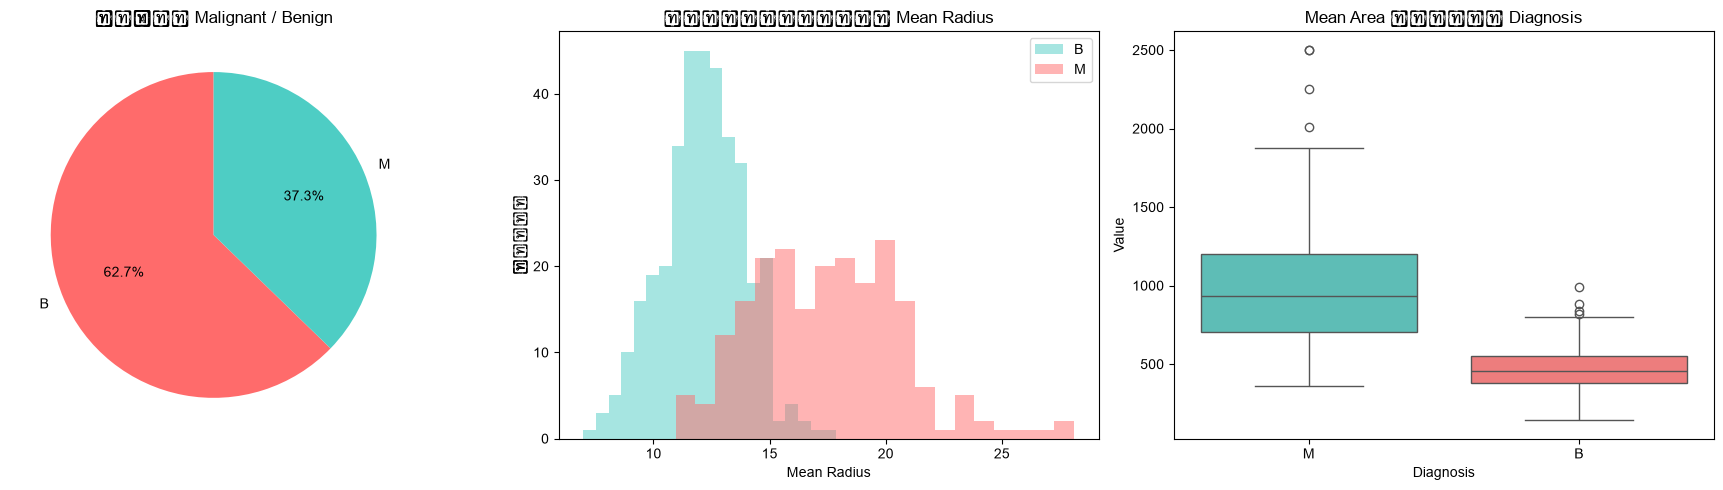

In [38]:
# Section 1 ต่อ: แสดงภาพข้อมูล

# 1. สัดส่วน Malignant vs Benign
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie Chart
diagnosis_counts = df['Diagnosis'].value_counts()
axes[0].pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%',
            colors=['#ff6b6b', '#4ecdc4'], startangle=90)
axes[0].set_title('สัดส่วน Malignant / Benign')

# Histogram ของ Mean Radius แยกตาม Diagnosis
for diag, color in [('B', '#4ecdc4'), ('M', '#ff6b6b')]:
    axes[1].hist(df[df['Diagnosis'] == diag]['Mean Radius'], bins=20, alpha=0.5, label=diag, color=color)
axes[1].set_xlabel('Mean Radius')
axes[1].set_ylabel('จำนวน')
axes[1].set_title('การกระจายของ Mean Radius')
axes[1].legend()

# Box Plot ของ Mean Area แยกตาม Diagnosis
df_melted = df.melt(id_vars=['Diagnosis'], value_vars=['Mean Area'], var_name='Feature', value_name='Value')
sns.boxplot(x='Diagnosis', y='Value', data=df_melted, palette=['#4ecdc4', '#ff6b6b'], ax=axes[2])
axes[2].set_title('Mean Area แยกตาม Diagnosis')

plt.tight_layout()
plt.show()

Feature Matrix X shape: (569, 30)
Target Vector y shape: (569,)

Label Encoding: ['B' 'M'] -> [0 1]
B (Benign) = 0, M (Malignant) = 1

หลัง Scaling - Mean: [-0.  0. -0. -0. -0.]
หลัง Scaling - Std: [1. 1. 1. 1. 1.]


/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2757241740.py:33: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2757241740.py:33: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2757241740.py:33: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/.venv-1/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/.venv-1/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  fig.canvas.print_fi

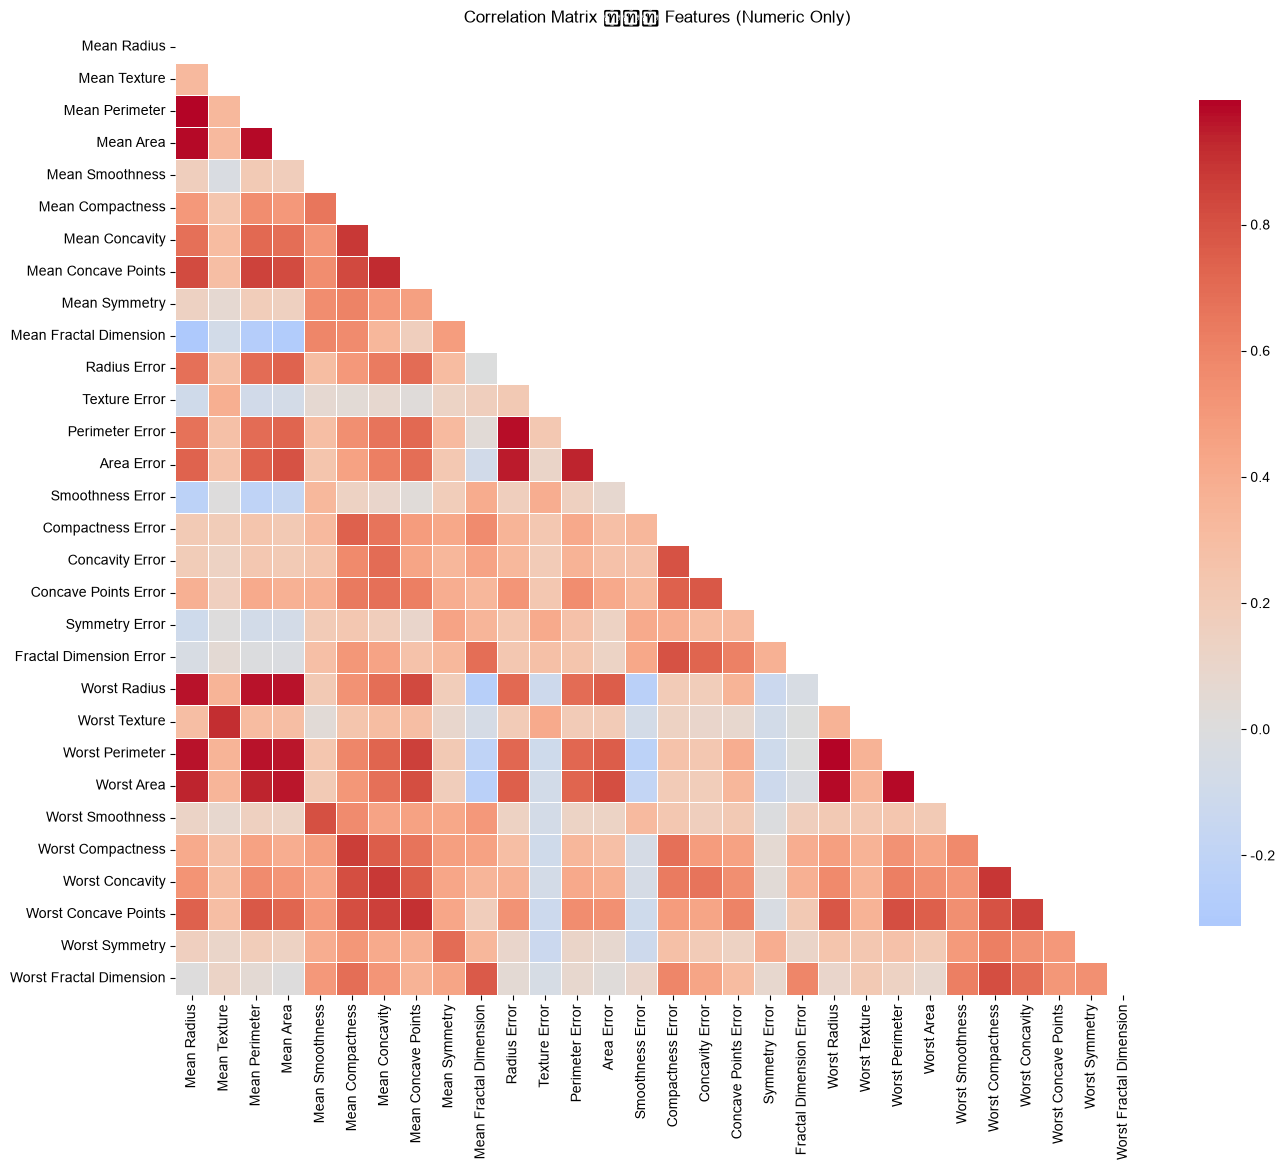

In [39]:
# Section 2: Preprocess Data

from sklearn.preprocessing import LabelEncoder, StandardScaler

# แยก Features (X) และ Target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

print(f'Feature Matrix X shape: {X.shape}')
print(f'Target Vector y shape: {y.shape}')

# แปลง Label เป็นตัวเลข (B=0, M=1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'\nLabel Encoding: {label_encoder.classes_} -> {np.unique(y_encoded)}')
print(f'B (Benign) = 0, M (Malignant) = 1')

# Feature Scaling ด้วย StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nหลัง Scaling - Mean: {X_scaled.mean(axis=0)[:5].round(4)}')
print(f'หลัง Scaling - Std: {X_scaled.std(axis=0)[:5].round(4)}')

# แสดง Correlation Heatmap (ใช้เฉพาะ numeric columns เท่านั้น)
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix ของ Features (Numeric Only)')
plt.tight_layout()
plt.show()

In [40]:
# Section 3: Split Dataset

from sklearn.model_selection import train_test_split

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded  # รักษาสัดส่วนคลาส
)

print('=== การแบ่งข้อมูล ===')
print(f'Training set: {X_train.shape[0]} ตัวอย่าง ({X_train.shape[0]/len(y_encoded)*100:.1f}%)')
print(f'Testing set: {X_test.shape[0]} ตัวอย่าง ({X_test.shape[0]/len(y_encoded)*100:.1f}%)')
print(f'\nTraining - Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}')
print(f'Testing - Benign: {sum(y_test==0)}, Malignant: {sum(y_test==1)}')

=== การแบ่งข้อมูล ===
Training set: 455 ตัวอย่าง (80.0%)
Testing set: 114 ตัวอย่าง (20.0%)

Training - Benign: 285, Malignant: 170
Testing - Benign: 72, Malignant: 42


In [41]:
# Section 4: Train Multiple Classification Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# สร้าง Model ทั้งหมด
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
}

# ฝึก Model แต่ละตัว
print('=== ฝึก Classification Models ===\n')
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✓ {name} trained successfully')

print('\n=== ฝึก Model เสร็จสิ้น ===')

=== ฝึก Classification Models ===

✓ Decision Tree trained successfully
✓ KNN (k=5) trained successfully
✓ Logistic Regression trained successfully
✓ Random Forest trained successfully
✓ SVM (RBF) trained successfully

=== ฝึก Model เสร็จสิ้น ===


/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/.venv-1/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [42]:
# Section 5: Evaluate Models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, \
    classification_report, confusion_matrix, ConfusionMatrixDisplay

# คำนวณ Metrics
results = {}
print('=== ผลการประเมิน Model ทุกตัว ===\n')

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    
    print(f'--- {name} ---')
    print(f'  Accuracy:  {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision: {prec:.4f} ({prec*100:.2f}%)')
    print(f'  Recall:    {rec:.4f} ({rec*100:.2f}%)')
    print(f'  F1-Score:  {f1:.4f} ({f1*100:.2f}%)')
    print()

# แสดงผลรวม
results_df = pd.DataFrame(results).T
print('=== สรุปผลเปรียบเทียบ ===')
display(results_df.round(4))

=== ผลการประเมิน Model ทุกตัว ===

--- Decision Tree ---
  Accuracy:  0.9298 (92.98%)
  Precision: 0.9048 (90.48%)
  Recall:    0.9048 (90.48%)
  F1-Score:  0.9048 (90.48%)

--- KNN (k=5) ---
  Accuracy:  0.9561 (95.61%)
  Precision: 0.9744 (97.44%)
  Recall:    0.9048 (90.48%)
  F1-Score:  0.9383 (93.83%)

--- Logistic Regression ---
  Accuracy:  0.9649 (96.49%)
  Precision: 0.9750 (97.50%)
  Recall:    0.9286 (92.86%)
  F1-Score:  0.9512 (95.12%)

--- Random Forest ---
  Accuracy:  0.9737 (97.37%)
  Precision: 1.0000 (100.00%)
  Recall:    0.9286 (92.86%)
  F1-Score:  0.9630 (96.30%)

--- SVM (RBF) ---
  Accuracy:  0.9737 (97.37%)
  Precision: 1.0000 (100.00%)
  Recall:    0.9286 (92.86%)
  F1-Score:  0.9630 (96.30%)

=== สรุปผลเปรียบเทียบ ===


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.9298,0.9048,0.9048,0.9048
KNN (k=5),0.9561,0.9744,0.9048,0.9383
Logistic Regression,0.9649,0.9750,0.9286,0.9512
Random Forest,0.9737,1.0000,0.9286,0.9630
SVM (RBF),0.9737,1.0000,0.9286,0.9630


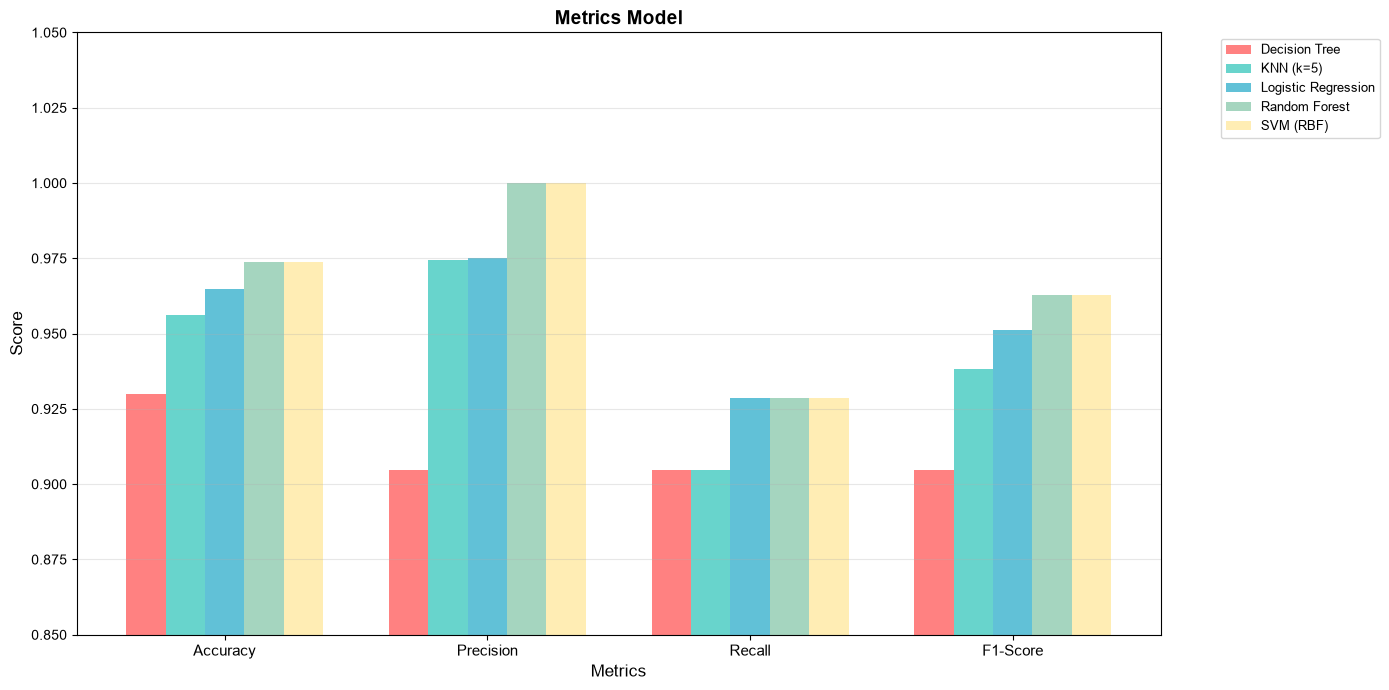

In [43]:
# Section 5 ต่อ: Visualization ของ Metrics

# Bar Chart เปรียบเทียบ Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7']

for i, (name, color) in enumerate(zip(trained_models.keys(), colors)):
    values = [results[name][m] for m in metrics_names]
    ax.bar(x + i*width, values, width, label=name, color=color, alpha=0.85)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metrics Model', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0.85, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.py:31: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.py:31: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.py:31: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.py:31: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.py:31: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/4204362191.p

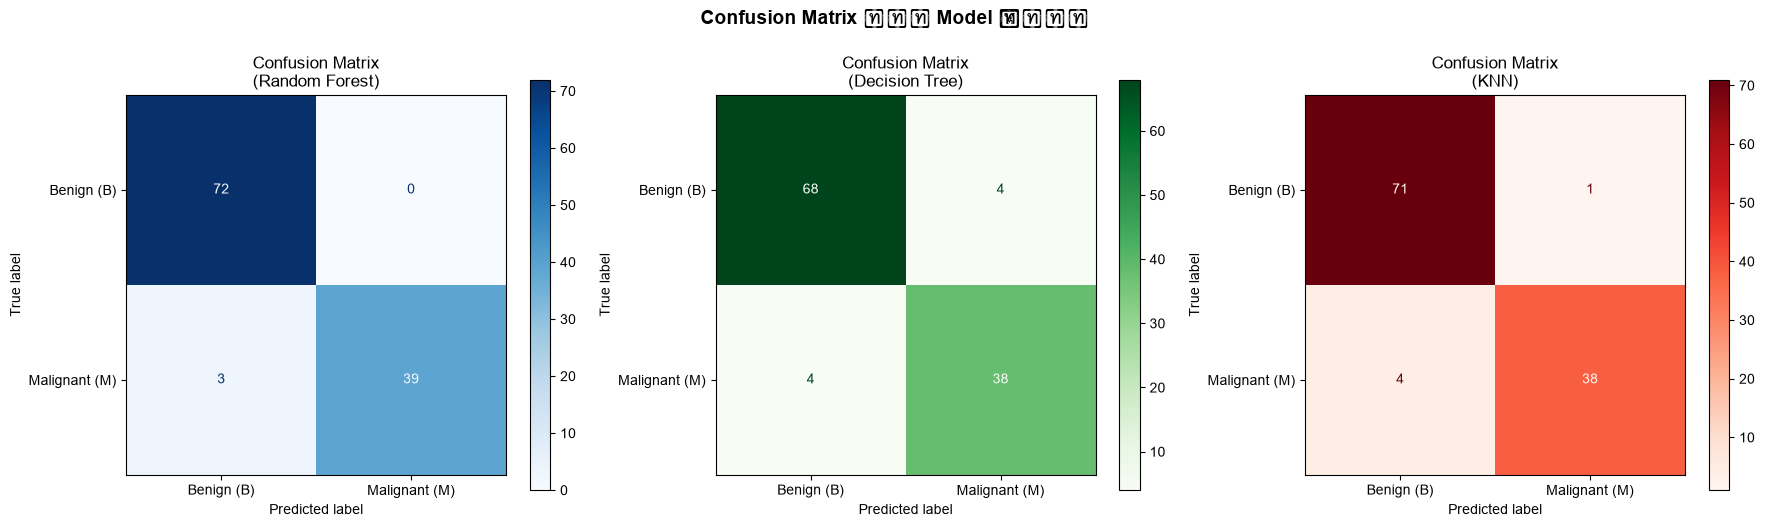

In [44]:
# Section 5 ต่อ: Confusion Matrix ของ Model ที่ดีที่สุด

# หา Model ที่ดีที่สุด (Highest Accuracy)
best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Best Model
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (B)', 'Malignant (M)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix\n({best_model_name})')

# 2. Confusion Matrix ของ Decision Tree
cm_dt = confusion_matrix(y_test, trained_models['Decision Tree'].predict(X_test))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Benign (B)', 'Malignant (M)'])
disp_dt.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix\n(Decision Tree)')

# 3. Confusion Matrix ของ KNN
cm_knn = confusion_matrix(y_test, trained_models['KNN (k=5)'].predict(X_test))
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Benign (B)', 'Malignant (M)'])
disp_knn.plot(ax=axes[2], cmap='Reds', values_format='d')
axes[2].set_title('Confusion Matrix\n(KNN)')

plt.suptitle('Confusion Matrix ของ Model ต่างๆ', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [45]:
# Section 5 ต่อ: Classification Report ของ Model ที่ดีที่สุด

print(f'=== Classification Report — {best_model_name} ===\n')
print(classification_report(y_test, y_pred_best, target_names=['Benign (B)', 'Malignant (M)']))

# อธิบายผลลัพธ์
print('=== คำอธิบาย Metrics ===')
print('''
 Accuracy = (TP + TN) / (TP + TN + FP + FN)
    อัตราส่วนที่ถูกต้องทั้งหมด (ทั้ง Benign และ Malignant)

 Precision = TP / (TP + FP)
    จากที่พยากรณ์ว่าเป็น Malignant, มีกี่เปอร์เซ็นต์ที่เป็น Malignant จริง
    Precision สูง = False Positive น้อย (ไม่เตือนผิด)

 Recall = TP / (TP + FN)
    จากที่เป็น Malignant จริง, มีกี่เปอร์เซ็นต์ที่พยากรณ์ถูก
    Recall สูง = False Negative น้อย (ไม่พลาดมะเร็ง)
     ในทางการแพทย์ Recall สำคัญมาก — ไม่ควรพลาดมะเร็ง

 F1-Score = 2 x (Precision x Recall) / (Precision + Recall)
    ค่าเฉลี่ยที่สมดุลระหว่าง Precision และ Recall
''')

=== Classification Report — Random Forest ===

               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114

=== คำอธิบาย Metrics ===

 Accuracy = (TP + TN) / (TP + TN + FP + FN)
    อัตราส่วนที่ถูกต้องทั้งหมด (ทั้ง Benign และ Malignant)

 Precision = TP / (TP + FP)
    จากที่พยากรณ์ว่าเป็น Malignant, มีกี่เปอร์เซ็นต์ที่เป็น Malignant จริง
    Precision สูง = False Positive น้อย (ไม่เตือนผิด)

 Recall = TP / (TP + FN)
    จากที่เป็น Malignant จริง, มีกี่เปอร์เซ็นต์ที่พยากรณ์ถูก
    Recall สูง = False Negative น้อย (ไม่พลาดมะเร็ง)
     ในทางการแพทย์ Recall สำคัญมาก — ไม่ควรพลาดมะเร็ง

 F1-Score = 2 x (Precision x Recall) / (Precision + Recall)
    ค่าเฉลี่ยที่สมดุลระหว่าง Precision และ Recall



/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2734958484.py:22: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2734958484.py:22: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2734958484.py:22: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2734958484.py:22: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nq/pbszq1fn3ddbzbwcrvk57_hc0000gn/T/ipykernel_55094/2734958484.py:22: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/pasunimsuwan/Desktop/DPU/DT-514/W5/.venv-1/lib/python3.12/site-pa

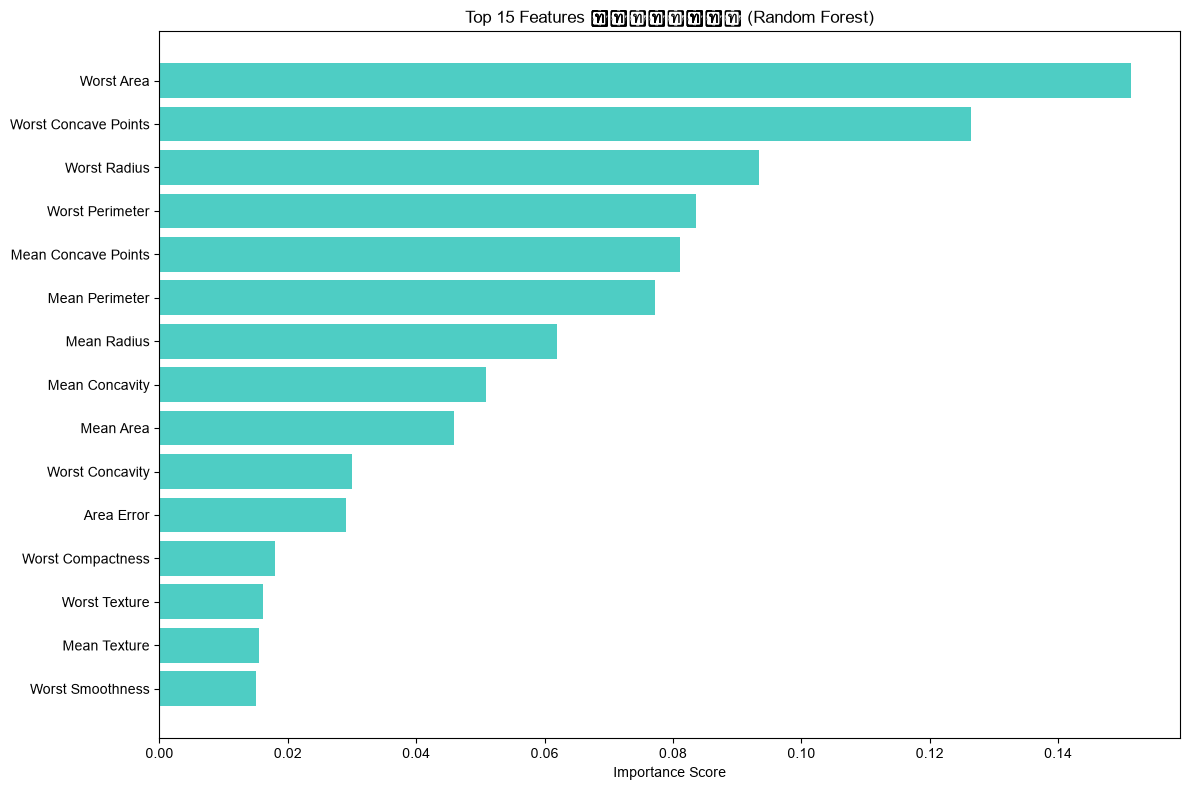

=== Top 10 Features สำคัญที่สุด ===


,Feature,Importance
23,Worst Area,0.1514
27,Worst Concave Points,0.1265
20,Worst Radius,0.0935
22,Worst Perimeter,0.0836
7,Mean Concave Points,0.0811
2,Mean Perimeter,0.0771
0,Mean Radius,0.0620
6,Mean Concavity,0.0508
3,Mean Area,0.0459
26,Worst Concavity,0.0300


In [46]:
# Section 5 ต่อ: Feature Importance (จาก Decision Tree / Random Forest)

# Feature Importance จาก Random Forest
rf_importance = trained_models['Random Forest'].feature_importances_
feature_names = X.columns

# เรียงตามความสำคัญ
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

# แสดง Top 15 Features ที่สำคัญที่สุด
top_15 = importance_df.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_15)), top_15['Importance'].values, color='#4ecdc4')
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Features ที่สำคัญที่สุด (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('=== Top 10 Features สำคัญที่สุด ===')
display(importance_df.head(10).round(4))

In [47]:
# สรุปผลทั้งหมด

print('='*60)
print('   สรุปผลการทดลอง Classification — WDBC Dataset')
print('='*60)

print('\n คำถาม 1: Classification Problem คืออะไร?')
print('    การจัดหมวดหมู่ข้อมูลใหม่เข้าไปในคลาสที่กำหนดล่วงหน้า')
print('    ตัวอย่าง: Malignant/Benign, Yes/No, ประเภทดอกไม้')

print('\n คำถาม 2: ทำไม ML ถึงแก้ปัญหาได้?')
print('    ML เรียนรู้ความสัมพันธ์ระหว่าง Features (30 ค่า) กับ Label (Diagnosis)')
print('    จาก Training Data >> สร้างกฎ >> ใช้พยากรณ์ข้อมูลใหม่')

print('\n คำถาม 3: เทคนิคที่ใช้?')
print('    Decision Tree, KNN, Logistic Regression, Random Forest, SVM')

print('\n คำถาม 4: สร้าง Model ได้อย่างไร?')
print('    ใช้ Scikit-learn: fit() >> predict() >> evaluate()')

print('\n คำถาม 5: Model ดีพอหรือไม่?')
print(f'    Model ที่ดีที่สุด: {best_model_name}')
print(f'    Accuracy:  {results[best_model_name]["Accuracy"]*100:.2f}%')
print(f'    Precision: {results[best_model_name]["Precision"]*100:.2f}%')
print(f'    Recall:    {results[best_model_name]["Recall"]*100:.2f}%')

print('\n สรุป: Model ทั้งหมดมี Accuracy > 90% — เหมาะสมสำหรับการใช้งาน')
print('   ในทางการแพทย์ ควรเลือก Model ที่มี Recall สูงสุด เพื่อไม่ให้พลาดมะเร็ง')

   สรุปผลการทดลอง Classification — WDBC Dataset

 คำถาม 1: Classification Problem คืออะไร?
    การจัดหมวดหมู่ข้อมูลใหม่เข้าไปในคลาสที่กำหนดล่วงหน้า
    ตัวอย่าง: Malignant/Benign, Yes/No, ประเภทดอกไม้

 คำถาม 2: ทำไม ML ถึงแก้ปัญหาได้?
    ML เรียนรู้ความสัมพันธ์ระหว่าง Features (30 ค่า) กับ Label (Diagnosis)
    จาก Training Data >> สร้างกฎ >> ใช้พยากรณ์ข้อมูลใหม่

 คำถาม 3: เทคนิคที่ใช้?
    Decision Tree, KNN, Logistic Regression, Random Forest, SVM

 คำถาม 4: สร้าง Model ได้อย่างไร?
    ใช้ Scikit-learn: fit() >> predict() >> evaluate()

 คำถาม 5: Model ดีพอหรือไม่?
    Model ที่ดีที่สุด: Random Forest
    Accuracy:  97.37%
    Precision: 100.00%
    Recall:    92.86%

 สรุป: Model ทั้งหมดมี Accuracy > 90% — เหมาะสมสำหรับการใช้งาน
   ในทางการแพทย์ ควรเลือก Model ที่มี Recall สูงสุด เพื่อไม่ให้พลาดมะเร็ง
